### PPG with Mamba

In [2]:
from __future__ import annotations
from typing import Dict, Any

import torch
from pathlib import Path

from ppg_task import PPGTask
from src.train_utils.trainer import Trainer

### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory from src.utils.block_factory for consistent configuration.

In [3]:
from src.utils.block_factory import make_mamba_block_cfg_ctor

In [7]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "ppg" / "data")

TRAIN_SUBJECTS = ("S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8")
VAL_SUBJECT = "S9"
TEST_SUBJECT = "S10"

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "pin_memory": False,
        "persistent_workers": False,
        # PPGDaliaConfig parameters
        "subjects_train": TRAIN_SUBJECTS,
        "subject_val": VAL_SUBJECT,
        "subject_test": TEST_SUBJECT,
        "fs_in": 64.0,
        "fs": 100.0,
        "win_sec": 8,
        "stride_sec": 2,
        "do_bandpass": True,
        "low_hz": 0.5,
        "high_hz": 8.0,
    },

    "epochs": 100,
    "lr": 5e-4,
    "wd": 1e-4,
    "grad_clip": 1.0,  # Important: prevent NaN/Inf when SSM params don't have weight decay
    "amp": False,
    "save_dir": "./runs/ppg_mamba_task",
    "warmup_epochs": 5,
    "patience": 10,
    "min_delta": 0.01,

    "d_model": 64,
    "depth": 4,
    "dropout": 0.2,
    "mlp_ratio": 2.0,
    "droppath_final": 0.1,
    "layerscale_init": 1e-2,
    "residual_gain": 1.0,
    "pool": "mean",

    # Mamba-specific parameters
    "d_state": 8,
    "expand_factor": 2,
    "d_conv": 4,
    "use_external_mlp": False,
}

args["block_cfg_ctor"] = make_mamba_block_cfg_ctor(
    d_state=args["d_state"],
    expand_factor=args["expand_factor"],
    d_conv=args["d_conv"],
    use_external_mlp=args["use_external_mlp"],
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS (Apple Silicon)")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU")

Using MPS (Apple Silicon)


### Training
With the configuration set up, we can now instantiate the `PPGTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation MAE.

In [5]:
from src.utils.visualization import plot_regression_history as plot_history

In [ ]:
task = PPGTask()

if torch.backends.mps.is_available() and args["device"].type == "mps":
    torch.mps.set_per_process_memory_fraction(0.9)

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best MAE={best_metric:.4f} @ {ckpt_path}")

Loaded checkpoint from epoch 14
Val metrics: {'loss': 205.44343511417756, 'time_s': 8.34645279700635, 'mse': 205.44343511417756, 'mae': 10.91286697726621}


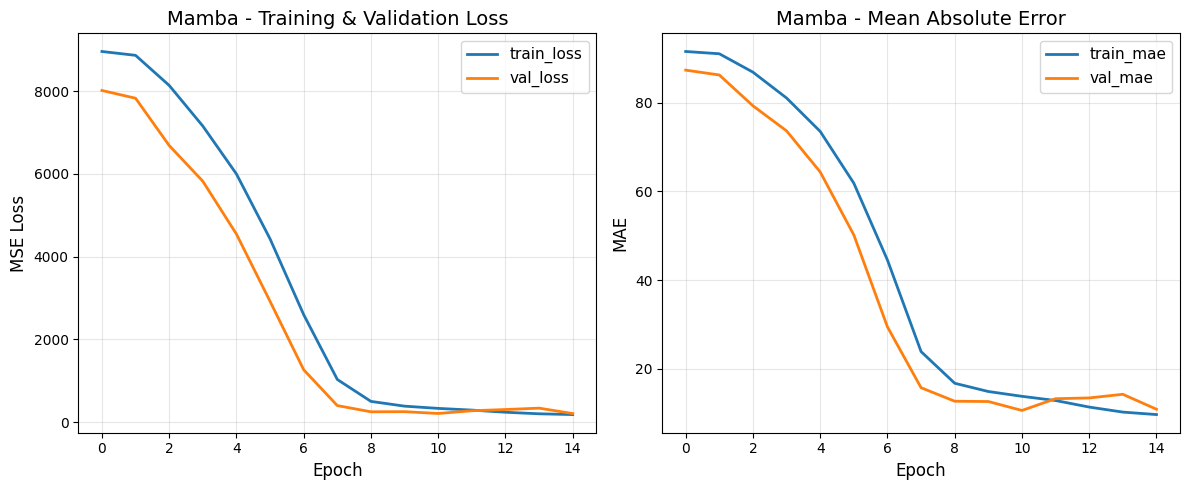

In [8]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=PPGTask(),
)

history = trainer.history

plot_history(history, model_name="Mamba")

In [11]:
from src.utils.common import print_model_details

print_model_details(model=trainer.model)


                            MODEL DETAILS                             

                             ARCHITECTURE                             
----------------------------------------------------------------------
Model Type: SeqClassifier
Core Layer Type: MambaCoreAdapter
Number of Blocks: 4

                              PARAMETERS                              
----------------------------------------------------------------------
Total parameters:                232,453
Trainable parameters:            232,453
Non-trainable parameters:              0
Model size (MB):                    0.89

                           MODEL ATTRIBUTES                           
----------------------------------------------------------------------

                           MODULE BREAKDOWN                           
----------------------------------------------------------------------
proj                           Linear                                320
blocks                         ModuleLi

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including MAE and RMSE, are printed.

In [10]:
from src.eval.eval_utils import evaluate_regression_model as evaluate_best_model

preds_test, targets_test = evaluate_best_model(
    args=args,
    task=PPGTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
)

Evaluating best model on the test set...
Loaded checkpoint from epoch 14
Val metrics: {'loss': 205.44343511417756, 'time_s': 8.34645279700635, 'mse': 205.44343511417756, 'mae': 10.91286697726621}
Val MSE: 205.443435, Val MAE: 10.912867


Testing:   0%|          | 0/42 [00:00<?, ?it/s]


TEST SET RESULTS:
MSE:  148.116287
MAE:  8.975374
RMSE: 12.170303
Test results saved to: runs/ppg_mamba_task/test_results.json


### Changes in dataset length

In [ ]:
from src.eval.eval_utils import evaluate_regression_model as evaluate_best_model

if torch.backends.mps.is_available() and args["device"].type == "mps":
    torch.mps.set_per_process_memory_fraction(0.9)


for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/ppg_mamba_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=PPGTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation MAE: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history, model_name="Mamba")

    preds_test, targets_test = evaluate_best_model(
        args=args,
        task=PPGTask(),
        best_model_path=best_path,
    )
